860 image with 2 esp = 0.0001 and 0.0003 / k=10 and k=all

In [ ]:
import pandas as pd
CSV_PATH = f"../results/all_2eps_2pert/combined_results.csv"
df = pd.read_csv(CSV_PATH)

In [ ]:
import numpy as np

# numeric safety
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["lb_minus_rhs"] = pd.to_numeric(df["lb_minus_rhs"], errors="coerce")

# make sure domains_visited exists
assert "domains_visited" in df.columns

# BnB flag
df["bnb_entered"] = df["domains_visited"] > 0

# result mapping
RESULT_RENAME = {
    "sat True": "Unsafe (counterexample)",
    "unsat False": "Safe (proved)",
    "timeout False": "Timeout / Unknown",
    "error": "Error",
    "sat False": "Unsafe (counterexample with BnB)",
}

df["result_label"] = df["result"].map(RESULT_RENAME).fillna(df["result"])

df["glb_status"] = np.where(
    np.isfinite(df["lb_minus_rhs"]),
    "Finite lower bound",
    "Lower bound = -inf"
)

summary = (
    df
    .groupby(["result_label", "bnb_entered", "glb_status"])
    .size()
    .reset_index(name="Count")
)

summary

,result_label,bnb_entered,glb_status,Count
0,Error,False,Lower bound = -inf,85
1,Safe (proved),False,Finite lower bound,2015
2,Timeout / Unknown,False,Lower bound = -inf,4717
3,Timeout / Unknown,True,Finite lower bound,290
4,Unsafe (counterexample with BnB),False,Lower bound = -inf,1641
5,Unsafe (counterexample),False,Lower bound = -inf,1586


In [14]:
import pandas as pd
GROUP_COL = "image"             # or "instance_id"

# ---- 1) Load + normalize
df = pd.read_csv(CSV_PATH)

for c in ["tag", GROUP_COL]:
    df[c] = df[c].astype(str).str.strip()

# (optional) make tag comparisons case-insensitive
df["tag_norm"] = df["tag"].str.lower()

# ---- 2) Define the exact expected 12 tags per label
# Edit this list to match your REAL tag strings exactly.
EXPECTED_TAGS = [
    # 4 globals (example: 2 eps * 2 k, etc.)  <-- replace with your real 12
    "n01440764_tench_global",
    "n01440764_tench_sego_fixmask",
    "n01440764_tench_sego_fixnonmask",
    # ... add the remaining 9 ...
]

# If your tags include the label prefix (like n01440764_tench_*), the above won't work globally.
# Usually you want expected "suffixes" instead, e.g.:
#   ["global", "seg0_fixmask", "seg0_fixnonmask", ...]
# Then check by pattern.
#
# If you truly mean "12 rows per label" regardless of exact names,
# you can skip EXPECTED_TAGS entirely and just count rows (see below).

# ---- 3) Basic check: exactly 12 rows per label
counts = df.groupby(GROUP_COL).size().rename("n_rows")
bad_count = counts[counts != 12].reset_index()

print("Labels with row-count != 12:")
print(bad_count if len(bad_count) else "None ✅")

# ---- 4) Stronger check: per label, check missing/extra tags vs expected
# If you DON'T want this, you can delete this whole section.
expected_set = set([t.strip().lower() for t in EXPECTED_TAGS])

def tag_set_for_group(g: pd.DataFrame):
    return set(g["tag_norm"].tolist())

rows = []
for label, g in df.groupby(GROUP_COL):
    got = tag_set_for_group(g)
    missing = sorted(list(expected_set - got))
    extra = sorted(list(got - expected_set))
    rows.append({
        GROUP_COL: label,
        "n_rows": len(g),
        "missing_tags": missing,
        "extra_tags": extra,
        "complete_12_expected": (len(g) == 12) and (len(missing) == 0) and (len(extra) == 0),
    })

coverage = pd.DataFrame(rows).sort_values(["complete_12_expected", "n_rows", GROUP_COL])

print("\nCoverage report (first 30 rows):")
print(coverage.head(30))

print("\nIncomplete labels:")
print(coverage[coverage["complete_12_expected"] == False][[GROUP_COL, "n_rows", "missing_tags", "extra_tags"]])

Labels with row-count != 12:
                 image  n_rows
0  n03250847_drumstick      14

Coverage report (first 30 rows):
                                 image  n_rows  \
0                      n01440764_tench      12   
1                   n01443537_goldfish      12   
2          n01484850_great_white_shark      12   
3                n01491361_tiger_shark      12   
4               n01496331_electric_ray      12   
5                       n01514668_cock      12   
6                        n01514859_hen      12   
7                    n01518878_ostrich      12   
8                  n01530575_brambling      12   
9                  n01531178_goldfinch      12   
10               n01532829_house_finch      12   
11                     n01534433_junco      12   
12            n01537544_indigo_bunting      12   
13                     n01558993_robin      12   
14                    n01560419_bulbul      12   
15                       n01580077_jay      12   
16                    n01

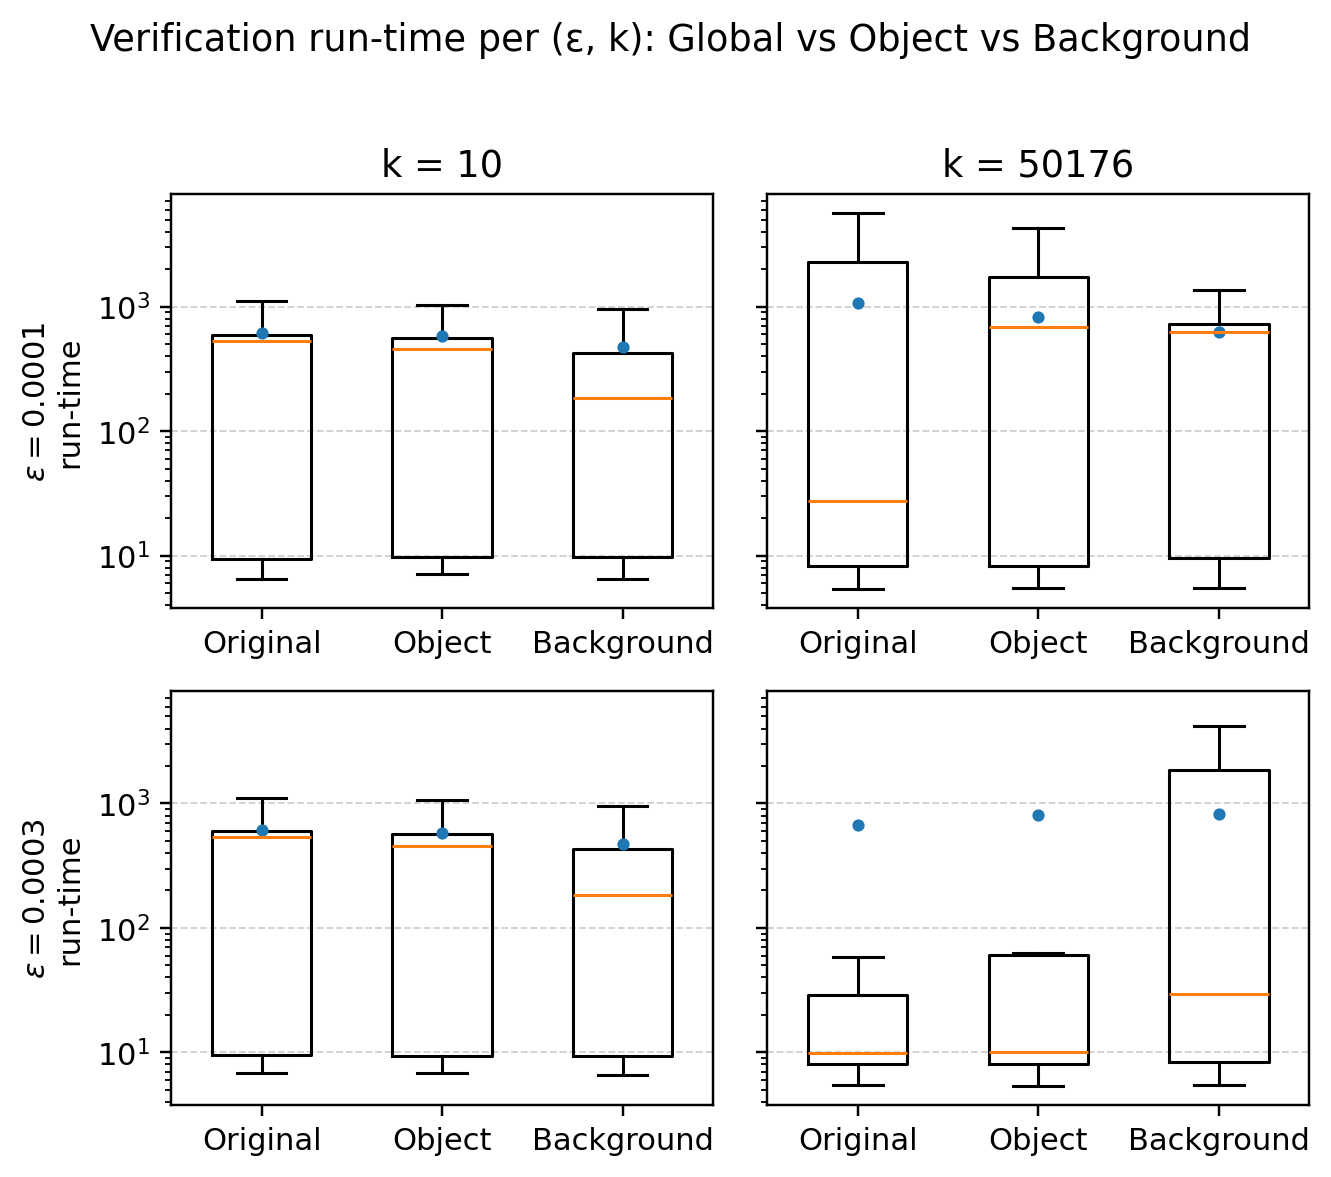

In [ ]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# Helpers
# ---------------------------
TIME_COL = "all_time" if "all_time" in df.columns else "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[TIME_COL] = pd.to_numeric(out[TIME_COL], errors="coerce")
    out = out.dropna(subset=["eps", "k", TIME_COL]).copy()
    out = out[out[TIME_COL] > 0].copy()
    return out

def grouped_boxplot_one_panel(ax, triplet_data, labels, show_means=True):
    """
    triplet_data: [global_times, object_times, background_times]
    """
    ax.boxplot(triplet_data, tick_labels=labels, showfliers=False, widths=0.55)

    if show_means:
        means = [np.mean(v) if len(v) else np.nan for v in triplet_data]
        ax.plot([1, 2, 3], means, marker="o", linestyle="none", markersize=3)

    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# ---------------------------
# Build subsets (KEEPING YOUR STYLE, but FIXED SEMANTICS)
# ---------------------------

# Global
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

# Object verification = fix_nonmask (background fixed)
# (your previous "seg + mask excluding non-mask" was unreliable)
df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))

# Background verification = fix_mask (object fixed)
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

# Sanitize
df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# Decide which eps and k to plot (12 panels)
# ---------------------------
# Use common eps across all three so panels are comparable
eps_vals = sorted(set(df_global["eps"]) & set(df_object["eps"]) & set(df_background["eps"]))

# Use common k across all three
k_vals = sorted(set(df_global["k"]) & set(df_object["k"]) & set(df_background["k"]))

# If you want EXACTLY 4 eps × 3 k = 12 panels, trim here if needed:
# eps_vals = eps_vals[:4]
# k_vals = k_vals[:3]

# ---------------------------
# Plot grid: rows=eps, cols=k  (=> 4x3 = 12)
# ---------------------------
rows = len(eps_vals)
cols = len(k_vals)

fig, axes = plt.subplots(rows, cols, figsize=(cols*3.1, rows*2.6), dpi=220, sharey=True)
axes = np.array(axes).reshape(rows, cols)

xlabels = [
    "Original",
    "Object",
    "Background",
]

for i, eps in enumerate(eps_vals):
    for j, k in enumerate(k_vals):
        ax = axes[i, j]

        g = df_global[(df_global["eps"] == eps) & (df_global["k"] == k)][TIME_COL].values
        o = df_object[(df_object["eps"] == eps) & (df_object["k"] == k)][TIME_COL].values
        b = df_background[(df_background["eps"] == eps) & (df_background["k"] == k)][TIME_COL].values

        grouped_boxplot_one_panel(ax, [g, o, b], xlabels, show_means=True)

        # Titles: keep compact
        if i == 0:
            ax.set_title(f"k = {int(k)}")
        if j == 0:
            ax.set_ylabel(rf"$\epsilon={eps:g}$" + "\nrun-time")

        ax.set_yscale("log")

# overall title
fig.suptitle("Verification run-time per (ε, k): Global vs Object vs Background", y=1.02)

plt.tight_layout()
plt.show()

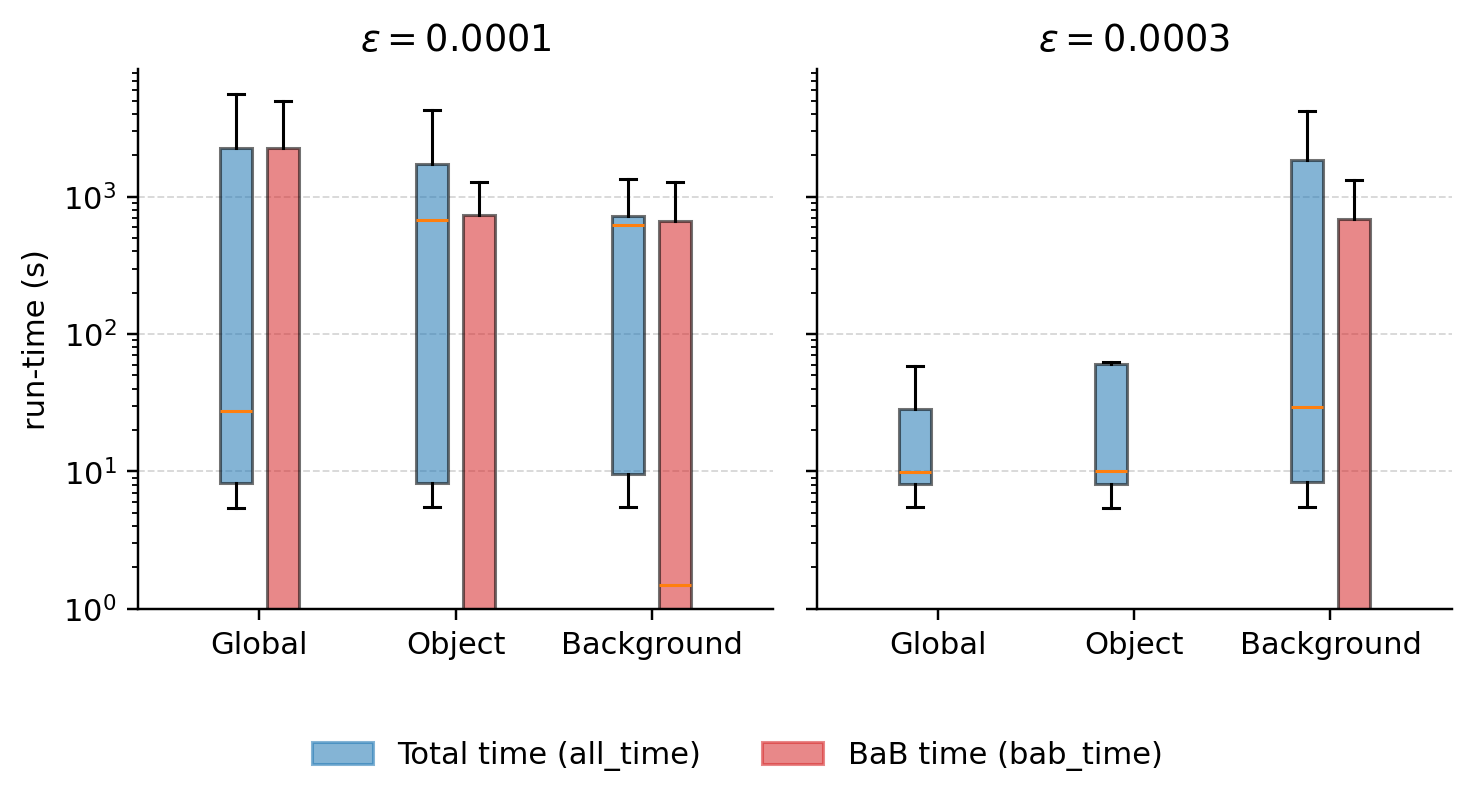

In [16]:
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ---------------------------
# Helpers
# ---------------------------
ALL_COL = "all_time"
BAB_COL = "bab_time"

def filter_by_tag_contains(frame: pd.DataFrame, include_any=(), include_all=(), exclude_any=()):
    tag = frame["tag"].astype(str)
    keep = pd.Series(True, index=frame.index)

    if include_any:
        keep_any = pd.Series(False, index=frame.index)
        for s in include_any:
            keep_any |= tag.str.contains(s, case=False, na=False)
        keep &= keep_any

    for s in include_all:
        keep &= tag.str.contains(s, case=False, na=False)

    if exclude_any:
        for s in exclude_any:
            keep &= ~tag.str.contains(s, case=False, na=False)

    return frame[keep].copy()

def sanitize_numeric(frame: pd.DataFrame):
    out = frame.copy()
    out["eps"] = pd.to_numeric(out["eps"], errors="coerce")
    out["k"] = pd.to_numeric(out["k"], errors="coerce")
    out[ALL_COL] = pd.to_numeric(out[ALL_COL], errors="coerce")
    if BAB_COL in out.columns:
        out[BAB_COL] = pd.to_numeric(out[BAB_COL], errors="coerce")

    out = out.dropna(subset=["eps", "k", ALL_COL]).copy()
    out = out[out[ALL_COL] > 0].copy()

    if BAB_COL in out.columns:
        out[BAB_COL] = out[BAB_COL].fillna(0)
        out.loc[out[BAB_COL] < 0, BAB_COL] = 0

    return out

def paired_boxplot_one_panel(ax, data_pairs, base_labels):
    centers = np.arange(1, len(base_labels) + 1)

    pos_total = centers - 0.12
    pos_bab   = centers + 0.12

    total_data = [p[0] for p in data_pairs]
    bab_data   = [p[1] for p in data_pairs]

    bp1 = ax.boxplot(
        total_data, positions=pos_total, widths=0.16,
        showfliers=False, patch_artist=True
    )
    bp2 = ax.boxplot(
        bab_data, positions=pos_bab, widths=0.16,
        showfliers=False, patch_artist=True
    )

    for b in bp1["boxes"]:
        b.set_facecolor("#1f77b4")
        b.set_alpha(0.55)
    for b in bp2["boxes"]:
        b.set_facecolor("#d62728")
        b.set_alpha(0.55)

    for key in ["whiskers", "caps", "medians"]:
        for line in bp1[key]:
            line.set_linewidth(1.0)
        for line in bp2[key]:
            line.set_linewidth(1.0)

    ax.set_xticks(centers)
    ax.set_xticklabels(base_labels)
    ax.grid(True, axis="y", linestyle="--", linewidth=0.6, alpha=0.5)

# ---------------------------
# Build subsets
# ---------------------------
if "is_global" in df.columns:
    df_global = df[df["is_global"] == True].copy()
else:
    df_global = filter_by_tag_contains(df, include_any=("global",))

df_object = filter_by_tag_contains(df, include_any=("fixnonmask", "fix_nonmask", "fix_non_mask"))
df_background = filter_by_tag_contains(df, include_any=("fixmask", "fix_mask"))

df_global = sanitize_numeric(df_global)
df_object = sanitize_numeric(df_object)
df_background = sanitize_numeric(df_background)

# ---------------------------
# FIXED k silently
# ---------------------------
FIXED_K = 50176

df_global = df_global[df_global["k"] == FIXED_K]
df_object = df_object[df_object["k"] == FIXED_K]
df_background = df_background[df_background["k"] == FIXED_K]

# ---------------------------
# TWO EPS SIDE BY SIDE
# ---------------------------

eps_vals = sorted(eps_vals)

cols = len(eps_vals)
rows = 1

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.2),
    dpi=220,
    sharey=True,
)

axes = np.array(axes).reshape(1, cols)

base_labels = ["Global", "Object", "Background"]

for j, eps in enumerate(eps_vals):

    ax = axes[0, j]

    g_all = df_global[df_global["eps"] == eps][ALL_COL].values
    g_bab = df_global[df_global["eps"] == eps][BAB_COL].values

    o_all = df_object[df_object["eps"] == eps][ALL_COL].values
    o_bab = df_object[df_object["eps"] == eps][BAB_COL].values

    b_all = df_background[df_background["eps"] == eps][ALL_COL].values
    b_bab = df_background[df_background["eps"] == eps][BAB_COL].values

    paired_boxplot_one_panel(
        ax,
        data_pairs=[(g_all, g_bab), (o_all, o_bab), (b_all, b_bab)],
        base_labels=base_labels
    )

    ax.set_title(rf"$\epsilon={eps:g}$")

    ax.set_yscale("log")

    if j == 0:
        ax.set_ylabel("run-time (s)")

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---------------------------
# Title + legend
# ---------------------------

# fig.suptitle(
#    "Verification run-time per ε: total time with embedded BaB time",
#    y=1.05
# )

total_patch = mpatches.Patch(color="#1f77b4", alpha=0.55, label="Total time (all_time)")
bab_patch   = mpatches.Patch(color="#d62728", alpha=0.55, label="BaB time (bab_time)")

fig.legend(
    handles=[total_patch, bab_patch],
    loc="lower center",
    ncol=2,
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),
)

plt.tight_layout()
plt.show()

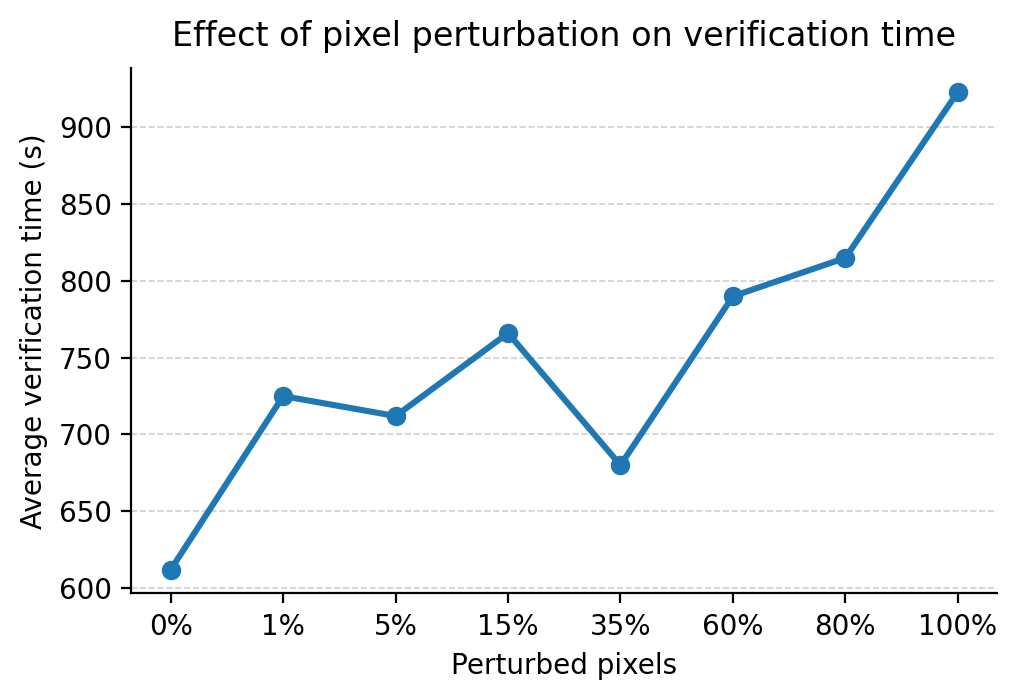

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# ---- your aggregated data (example) ----
pixel_vals = np.array([0, 1, 5, 15, 35, 60, 80, 100])
avg_time = np.array([612, 725, 712, 766, 680, 790, 815, 923])

# ---- categorical x positions (equal spacing) ----
x_pos = np.arange(len(pixel_vals))

# ---- plot ----
plt.figure(figsize=(5.2, 3.6), dpi=200)

plt.plot(
    x_pos,
    avg_time,
    marker="o",
    linewidth=2.2,
    markersize=6,
)

# ---- axis styling ----
plt.xticks(x_pos, [f"{p}%" for p in pixel_vals])
plt.xlabel("Perturbed pixels")
plt.ylabel("Average verification time (s)")

plt.title("Effect of pixel perturbation on verification time", pad=8)

# subtle grid (y only)
plt.grid(axis="y", linestyle="--", linewidth=0.6, alpha=0.6)

# remove top/right spines (paper style)
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

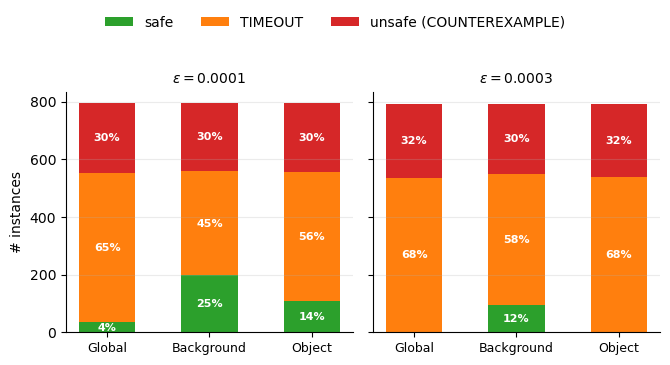

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# CONFIG
# -----------------------------
PAIR_COLS = ["image", "eps", "k"]

VARIANTS = ["Global", "Background", "Object"]
XTICK_LABELS = ["Global", "Background", "Object"]

RESULT_RENAME = {
    "unsat False": "safe",
    "timeout False": "TIMEOUT",
    "sat True": "unsafe (COUNTEREXAMPLE)",
}

RESULT_COLORS = {
    "unsafe (COUNTEREXAMPLE)": "#d62728",
    "safe": "#2ca02c",
    "TIMEOUT": "#ff7f0e",
}

RESULT_ORDER = ["safe", "TIMEOUT", "unsafe (COUNTEREXAMPLE)"]

FIXED_K = 50176   # silently restrict to this

# -----------------------------
# LOAD / CLEAN
# -----------------------------
df = df.copy()
df["eps"] = pd.to_numeric(df["eps"], errors="coerce")
df["k"]   = pd.to_numeric(df["k"], errors="coerce")
df["result"] = df["result"].astype(str)

# -----------------------------
# VARIANT CLASSIFIER
# -----------------------------
def classify_variant(row):
    pat = str(row.get("pattern", "")).lower()
    tag = str(row.get("tag", "")).lower()
    vnn = str(row.get("vnnlib", "")).lower()
    is_global = bool(row.get("is_global", False))

    if is_global or pat == "global" or "_global" in tag or "_global" in vnn:
        return "Global"

    s = " ".join([pat, tag, vnn])

    if any(k in s for k in ["fix_mask", "fix-mask", "fixmask"]):
        return "Background"
    if any(k in s for k in ["fix_nonmask", "fix-nonmask", "fixnonmask", "fix_non_mask"]):
        return "Object"

    if any(k in s for k in ["background", "bg", "nonmask", "non-mask"]):
        return "Background"
    if any(k in s for k in [" object", " obj", "foreground"]):
        return "Object"

    return None

df["variant"] = df.apply(classify_variant, axis=1)
df = df[df["variant"].isin(VARIANTS)].copy()

# Keep only seg0 for non-global
if "segment_index" in df.columns:
    df = df[(df["variant"] == "Global") | (df["segment_index"] == 0)].copy()

# Clean results
df = df[df["result"].isin(RESULT_RENAME)].copy()
df["result_clean"] = df["result"].map(RESULT_RENAME)

# -----------------------------
# PAIRED WIDE TABLE
# -----------------------------
res_all3 = df.pivot_table(
    index=PAIR_COLS,
    columns="variant",
    values="result_clean",
    aggfunc="first"
).reset_index()

res_all3 = res_all3.dropna(subset=VARIANTS).copy()

# -----------------------------
# FIX k SILENTLY
# -----------------------------
res_all3 = res_all3[res_all3["k"] == FIXED_K].copy()

# -----------------------------
# EPS PANELS SIDE BY SIDE
# -----------------------------
eps_values = sorted(res_all3["eps"].dropna().unique())

rows = 1
cols = len(eps_values)

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(cols * 3.4, 3.4),
    squeeze=False,
    sharey=True
)

x = np.arange(len(VARIANTS))

for j, eps in enumerate(eps_values):

    ax = axes[0][j]
    sub = res_all3[res_all3["eps"] == eps]

    bottom = np.zeros(len(VARIANTS), dtype=float)

    total_per_variant = np.array([len(sub)] * len(VARIANTS), dtype=float)

    for lab in RESULT_ORDER:

        vals = np.array([(sub[v] == lab).sum() for v in VARIANTS], dtype=float)
        pct  = np.divide(vals, total_per_variant, out=np.zeros_like(vals), where=total_per_variant > 0) * 100

        ax.bar(
            x,
            vals,
            bottom=bottom,
            width=0.55,
            color=RESULT_COLORS[lab],
            label=lab if j == 0 else None,
        )

        # percentage text
        for xi, v, p, btm in zip(x, vals, pct, bottom):
            if v > 0:
                ax.text(
                    xi,
                    btm + v / 2,
                    f"{p:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=8,
                    color="white",
                    weight="bold",
                )

        bottom += vals

    ax.set_xticks(x)
    ax.set_xticklabels(XTICK_LABELS, fontsize=9)
    ax.grid(True, axis="y", alpha=0.25)

    ax.set_title(rf"$\epsilon = {eps:g}$", fontsize=10)

    if j == 0:
        ax.set_ylabel("# instances", fontsize=10)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# -----------------------------
# Legend + title
# -----------------------------
handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, 1.08),
)

# fig.suptitle( "Outcome distribution by variant (fully paired by image and ε)", y=1.18, fontsize=11,)

plt.tight_layout(rect=[0, 0, 1, 0.92])
plt.show()

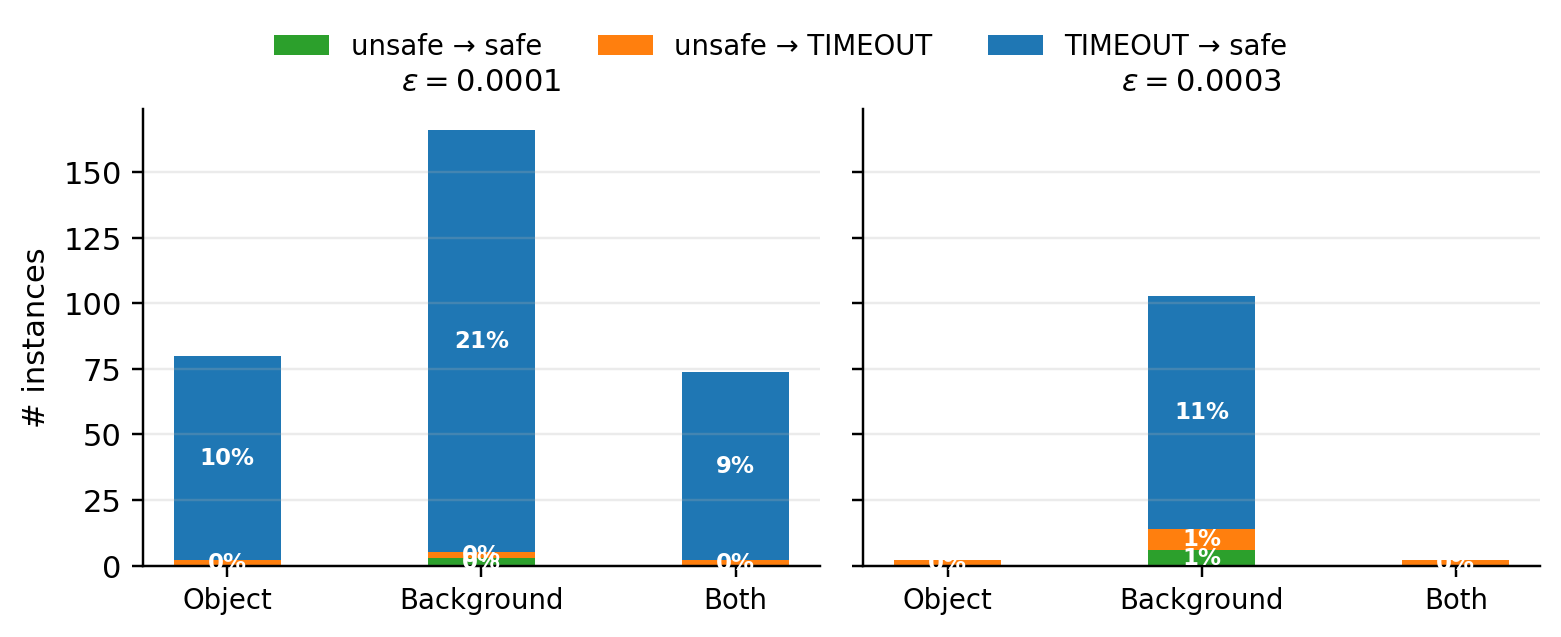

In [36]:
fig, axes = plt.subplots(
    1, len(panels),
    figsize=(len(panels) * 3.6, 3.0),
    dpi=220,
    sharey=True,
    squeeze=False
)

for j, panel in enumerate(panels):
    ax = axes[0, j]
    eps = panel["eps"]
    n_base = panel["n_base"]
    counts = panel["counts"]

    bottom = np.zeros(len(variants), dtype=float)

    for (src, dst) in TRANS_ORDER:

        raw = np.array(
            [counts[(src, dst)][v] for v in variants],
            dtype=float
        )

        ax.bar(
            x,
            raw,
            bottom=bottom,
            width=0.42,   # 🔥 thinner bars
            color=TRANS_COLOR[(src, dst)],
            label=TRANS_LABEL[(src, dst)] if j == 0 else None
        )

        # % labels (relative to global-fail set)
        if n_base > 0:
            for xi, v, btm in zip(x, raw, bottom):
                if v <= 0:
                    continue
                pct = 100.0 * v / n_base
                ax.text(
                    xi,
                    btm + v / 2,
                    f"{pct:.0f}%",
                    ha="center",
                    va="center",
                    fontsize=7.5,
                    color="white",
                    weight="bold"
                )

        bottom += raw

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, fontsize=9)
    ax.set_title(rf"$\epsilon = {eps:g}$", fontsize=10)

    if j == 0:
        ax.set_ylabel("# instances", fontsize=10)

    ax.grid(True, axis="y", alpha=0.25)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# ---- clean title ----
# fig.suptitle(
#    "Semantic recovery after global failure",
#    y=1.04,
#    fontsize=11
# )

# ---- legend lower + compact ----
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=9,
    bbox_to_anchor=(0.5, 0.97),
)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [34]:
# Long format: one row per (image, eps, k, variant)
long = res_all3.melt(
    id_vars=PAIR_COLS,
    value_vars=VARIANTS,
    var_name="variant",
    value_name="result"
)

# Count + percentage
pct_table = (
    long
    .groupby(["eps", "k", "variant", "result"])
    .size()
    .reset_index(name="count")
)

pct_table["percent"] = (
    pct_table
    .groupby(["eps", "k", "variant"])["count"]
    .transform(lambda x: 100 * x / x.sum())
)

pct_table = pct_table.sort_values(["eps", "k", "variant", "result"])
print(pct_table)

       eps      k     variant                   result  count    percent
0   0.0001  50176  Background                  TIMEOUT    361  45.408805
1   0.0001  50176  Background                     safe    197  24.779874
2   0.0001  50176  Background  unsafe (COUNTEREXAMPLE)    237  29.811321
3   0.0001  50176      Global                  TIMEOUT    519  65.283019
4   0.0001  50176      Global                     safe     34   4.276730
5   0.0001  50176      Global  unsafe (COUNTEREXAMPLE)    242  30.440252
6   0.0001  50176      Object                  TIMEOUT    445  55.974843
7   0.0001  50176      Object                     safe    110  13.836478
8   0.0001  50176      Object  unsafe (COUNTEREXAMPLE)    240  30.188679
9   0.0003  50176  Background                  TIMEOUT    455  57.522124
10  0.0003  50176  Background                     safe     95  12.010114
11  0.0003  50176  Background  unsafe (COUNTEREXAMPLE)    241  30.467762
12  0.0003  50176      Global                  TIME

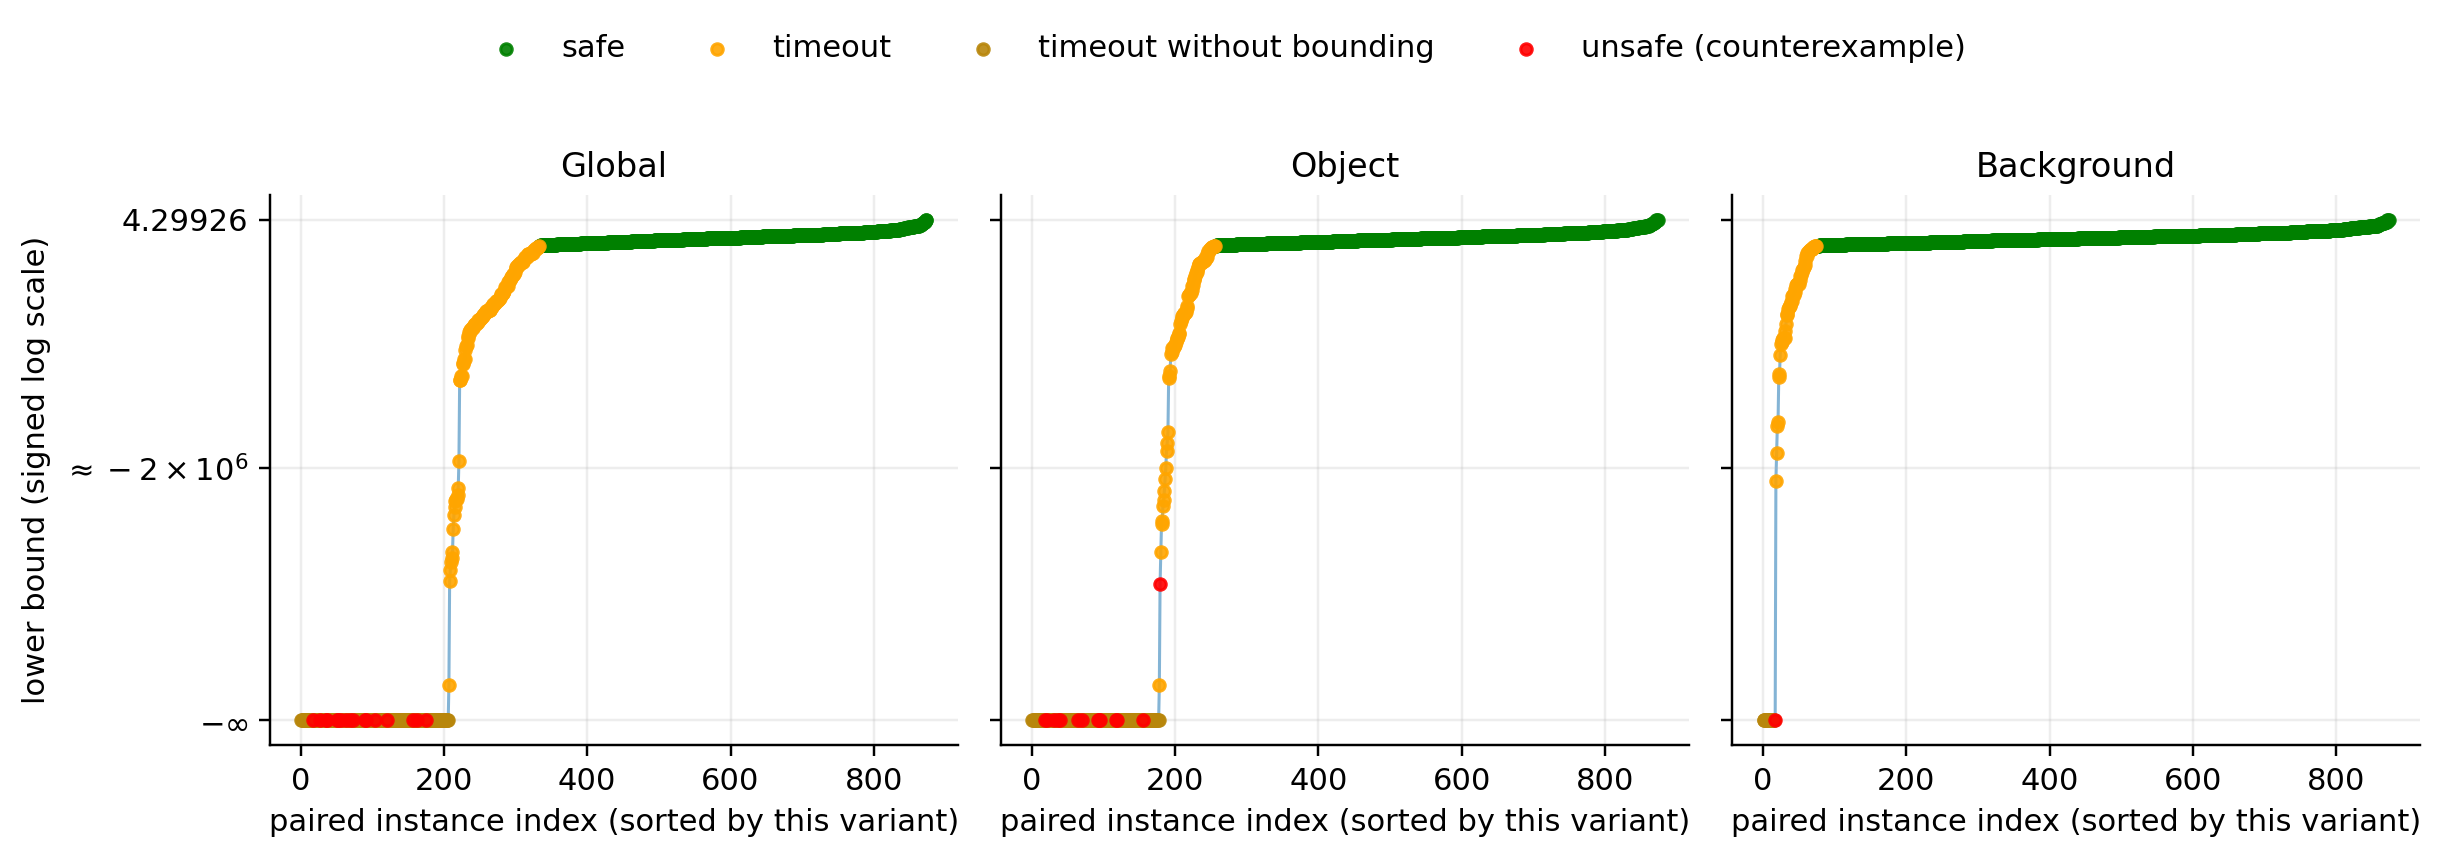

In [43]:
fig, axes = plt.subplots(1, 3, figsize=(11.2, 3.6), dpi=220, sharey=True)

variants = [
    ("Global", "Global_LB", "Global_res"),
    ("Object", "Object_LB", "Object_res"),
    ("Background", "Background_LB", "Background_res"),
]

for ax, (title, lb_col, res_col) in zip(axes, variants):

    # 🔥 sort paired instances BY THIS VARIANT
    order = paired.sort_values(lb_col, ascending=True).reset_index(drop=True)

    x = np.arange(1, len(order) + 1)
    y = y_from_lb(order[lb_col].values)

    # connecting line
    ax.plot(
        x,
        y,
        linewidth=1.0,
        alpha=0.55,
        zorder=1,
    )

    # scatter by result
    for cat in ["unsat", "timeout", "timeout_nobound", "sat", "other"]:
        sub = order[order[res_col] == cat]
        if sub.empty:
            continue

        ax.scatter(
            sub.index.values + 1,
            y_from_lb(sub[lb_col].values),
            s=14,
            alpha=0.9,
            c=COLOR[cat],
            label=LEGEND_LABEL.get(cat, cat),
            zorder=2,
        )

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("paired instance index (sorted by this variant)", fontsize=10)

    ax.grid(True, alpha=0.22)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# shared y
axes[0].set_ylabel("lower bound (signed log scale)", fontsize=10)
for ax in axes:
    ax.set_yticks(yticks)
    ax.set_yticklabels(ytlabs)

# legend once
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 1.09),
)

# fig.suptitle(
#    "Lower bound progression (paired instances; sorted per variant; missing LB at bottom)",
#    y=1.14,
#  fontsize=12,
# )

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()